<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB15b · Funciones a fondo: moverlas, la exponencial y el logaritmo

**Parte 2 · Las matemáticas del aprendizaje — Lección intermedia (entre el NB15 y el NB16)**

> En el NB04b conociste las **funciones**: máquinas que convierten una entrada en una salida, como `f(x) = 2·x + 1`. En la Parte 2 y en las siguientes vas a encontrar funciones que **se mueven** (en el NB19 construiremos curvas desplazando "codos"), y dos funciones muy especiales que aparecen por todas partes en robótica y en aprendizaje automático: la **exponencial** y el **logaritmo**.

Hoy las conocemos a fondo, con NumPy y dibujos (NB15). Tres bloques:

1. **Mover una función**: subirla, desplazarla, estirarla, darle la vuelta. Con una trampa de signo que confunde a todo el mundo.
2. **La exponencial** y el famoso número **e**: el crecimiento que se multiplica, el decaimiento que "se apaga", y la **constante de tiempo** que aparecerá en motores, filtros y contactos.
3. **El logaritmo**: la pregunta inversa ("¿a qué exponente?"), sus reglas mágicas que convierten multiplicaciones en sumas, y las **escalas logarítmicas** de las gráficas.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def dibujar(xs, curvas, titulo):
    # Dibuja varias curvas (una lista de parejas (ys, etiqueta)) sobre los mismos ejes.
    plt.figure(figsize=(6, 3.5))
    for ys, etiqueta in curvas:
        plt.plot(xs, ys, label=etiqueta)
    plt.axhline(0, color="k", lw=0.5)
    plt.axvline(0, color="k", lw=0.5)
    plt.title(titulo)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

(Una función de ayuda para no repetir las mismas líneas de dibujo en cada celda. Recibe los valores de x, una **lista de tuplas** (NB11b) con los valores de y y su etiqueta, y un título. `plt.axhline` y `plt.axvline` dibujan una línea horizontal y una vertical en el cero, para tener los ejes de referencia.)

## 1 · Mover una función

### La función de partida

Usaremos una función muy sencilla que reaparecerá en el NB19 como pieza básica de las redes neuronales: la **rampa** (su nombre técnico es **ReLU**). Vale **0** para los números negativos y **x** para los positivos: un "codo" en el cero.

```
   rampa(x) = 0   si x < 0
   rampa(x) = x   si x ≥ 0
```

En NumPy se escribe con `np.maximum(0, x)`: el mayor entre 0 y x, elemento a elemento.


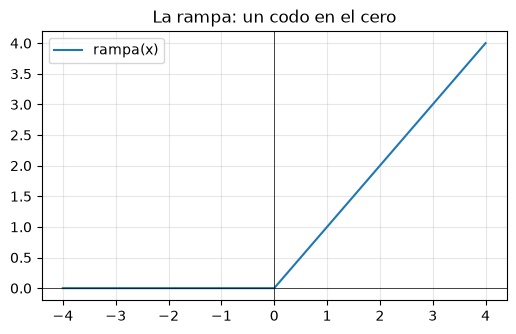

In [2]:
def rampa(x):
    return np.maximum(0, x)

xs = np.linspace(-4, 4, 401)            # 401 números repartidos entre -4 y 4
dibujar(xs, [(rampa(xs), "rampa(x)")], "La rampa: un codo en el cero")

(`np.linspace(inicio, fin, cuántos)` da números **repartidos por igual** entre el inicio y el fin, ambos incluidos: perfecto para dibujar curvas suaves.)

### Sumar fuera: subir y bajar

**`f(x) + c`** sube la curva entera **c** unidades (o la baja, si c es negativo). Fácil: a cada salida se le suma c.


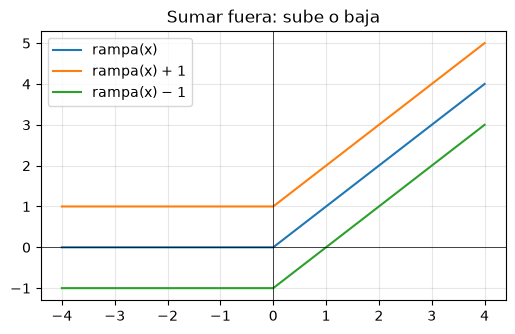

In [3]:
dibujar(xs, [(rampa(xs), "rampa(x)"), (rampa(xs) + 1, "rampa(x) + 1"), (rampa(xs) - 1, "rampa(x) − 1")],
        "Sumar fuera: sube o baja")

### Sumar dentro: desplazar (¡con el signo al revés!)

**`f(x − a)`** desplaza la curva **a unidades hacia la DERECHA**. Y **`f(x + a)`**, hacia la **IZQUIERDA**. Sí: con el signo menos va a la derecha. Es la trampa de signo más famosa de las matemáticas. Mira:


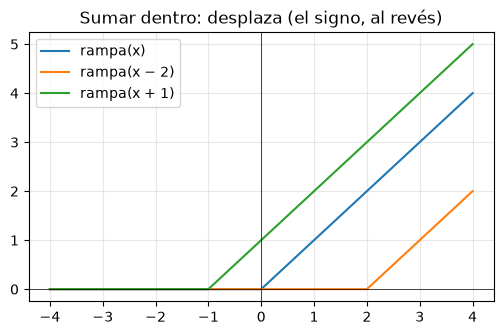

In [4]:
dibujar(xs, [(rampa(xs), "rampa(x)"), (rampa(xs - 2), "rampa(x − 2)"), (rampa(xs + 1), "rampa(x + 1)")],
        "Sumar dentro: desplaza (el signo, al revés)")

`rampa(x − 2)` tiene el codo en **x = 2** (a la derecha), y `rampa(x + 1)`, en **x = −1** (a la izquierda). ¿Por qué al revés? Piensa en **dónde está el codo**: la rampa original tiene el codo donde lo de dentro vale **0**. En `rampa(x − 2)`, lo de dentro es `x − 2`, que vale 0 cuando **x = 2**. Así que el codo está en 2. En `rampa(x + 1)`, lo de dentro vale 0 cuando x = −1.

**La regla para no equivocarse nunca: el punto especial se mueve a donde "lo de dentro" vale lo que valía antes.** Si tienes `rampa(x + 4/3)` (lo verás en el NB19), el codo está donde x + 4/3 = 0, es decir, en **x = −4/3**: despeja (NB04b) y sale.

### Multiplicar fuera: estirar en vertical

**`c · f(x)`** estira la curva en vertical (la hace c veces más alta). Con la rampa, cambia su **inclinación**: `3·rampa(x)` sube tres veces más deprisa. Y si c es **negativo**, la curva además se **da la vuelta** de arriba abajo (se refleja en el eje horizontal):


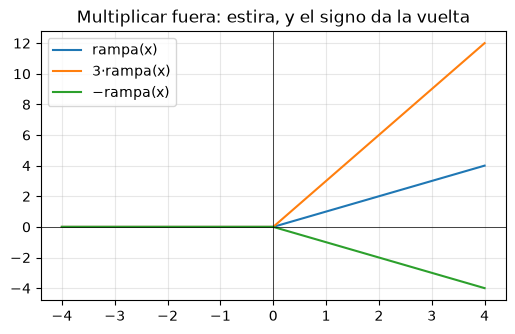

In [5]:
dibujar(xs, [(rampa(xs), "rampa(x)"), (3 * rampa(xs), "3·rampa(x)"), (-rampa(xs), "−rampa(x)")],
        "Multiplicar fuera: estira, y el signo da la vuelta")

### Cambiar el signo dentro: reflejar en horizontal

**`f(−x)`** refleja la curva de izquierda a derecha (como en un espejo vertical colocado en el cero). La rampa, que "subía hacia la derecha", pasa a subir hacia la **izquierda**:


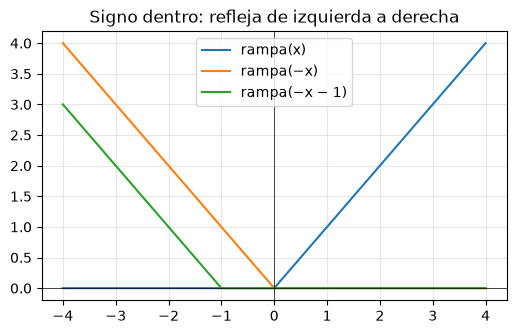

In [6]:
dibujar(xs, [(rampa(xs), "rampa(x)"), (rampa(-xs), "rampa(−x)"), (rampa(-xs - 1), "rampa(−x − 1)")],
        "Signo dentro: refleja de izquierda a derecha")

`rampa(−x)` vale 0 para los positivos y crece hacia los negativos. Y `rampa(−x − 1)` es eso mismo, con el codo donde lo de dentro vale 0: −x − 1 = 0 → x = **−1**. Combinando estas piezas (desplazar, estirar, reflejar, sumar) se puede fabricar casi cualquier forma: es exactamente lo que hace una red neuronal (NB19).

### Resumen de las transformaciones

| Escribes | La curva... |
|---|---|
| `f(x) + c` | sube c (baja si c < 0) |
| `f(x − a)` | se desplaza a a la **derecha** |
| `f(x + a)` | se desplaza a a la **izquierda** |
| `c · f(x)` | se estira c veces en vertical (y se da la vuelta si c < 0) |
| `f(−x)` | se refleja de izquierda a derecha |

Las de **fuera** (después de calcular f) actúan en **vertical** y "hacen lo que dicen". Las de **dentro** (antes de calcular f) actúan en **horizontal** y "hacen lo contrario de lo que parece".


## 2 · La exponencial

### Potencias con cualquier exponente

En el NB03b viste las potencias con exponentes enteros (2³ = 8), negativos (2⁻¹ = 0,5) y ½ (2^0,5 = √2). En realidad, el exponente puede ser **cualquier** número decimal: 2^1,5, 2^0,3, 2^π... y el resultado cambia **suavemente** entre los valores enteros. Con eso se puede dibujar la **función exponencial** `f(x) = 2ˣ` como una curva continua:


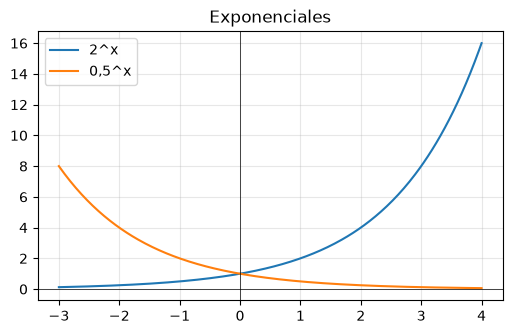

2^1,5 = 2.8284271247461903 | entre 2^1 = 2 y 2^2 = 4, como debe ser


In [7]:
xs = np.linspace(-3, 4, 300)
dibujar(xs, [(2.0 ** xs, "2^x"), (0.5 ** xs, "0,5^x")], "Exponenciales")
print("2^1,5 =", 2 ** 1.5, "| entre 2^1 = 2 y 2^2 = 4, como debe ser")

Tres cosas que hay que ver en esta gráfica:

1. **2ˣ crece cada vez más deprisa** (crecimiento exponencial, NB03b): cada vez que x sube 1, el valor se **multiplica por 2**. Por la izquierda se acerca a 0 sin llegar nunca.
2. **Nunca es negativa ni cero**: por pequeño que sea x, 2ˣ es positivo (2⁻¹⁰ = 1/1.024, chiquitito pero positivo). Esta propiedad la usaremos muchísimo (NB32: para que una "anchura" σ sea siempre positiva).
3. **0,5ˣ es la misma curva reflejada**: decrece, porque cada vez que x sube 1, se multiplica por 0,5 (se divide entre 2). Es el **decrecimiento exponencial** (sección 3).

### El número e

De todas las bases posibles para una exponencial (2, 10, 0,5...), hay una que los matemáticos prefieren por encima de todas: el número **e ≈ 2,71828**. Es tan importante como π, y aparece en cuanto algo **crece (o decrece) en proporción a lo que ya hay**.

¿De dónde sale? De una pregunta sobre dinero. Si el banco te da un 100 % de interés al año, tu euro se convierte en 2. Si te lo da en dos mitades (50 % cada seis meses), al final tienes 1,5 × 1,5 = 2,25 (porcentajes encadenados, NB03b). En 12 meses, un doceavo cada mes: (1 + 1/12)¹² ≈ 2,61. ¿Y si lo repartes en trocitos cada vez más pequeños?


In [8]:
for n in [1, 2, 12, 365, 10_000, 1_000_000]:
    print(f"{n:>9} trocitos: (1 + 1/n)^n = {(1 + 1 / n) ** n:.6f}")
print(f"el número e:                     {np.e:.6f}")

        1 trocitos: (1 + 1/n)^n = 2.000000
        2 trocitos: (1 + 1/n)^n = 2.250000
       12 trocitos: (1 + 1/n)^n = 2.613035
      365 trocitos: (1 + 1/n)^n = 2.714567
    10000 trocitos: (1 + 1/n)^n = 2.718146
  1000000 trocitos: (1 + 1/n)^n = 2.718280
el número e:                     2.718282


Cuantos más trocitos, más se acerca a un número concreto, que **no** pasa de ahí: **e = 2,718281828...** (con cifras que nunca terminan, como π). Es el resultado de crecer "de forma continua", sin saltos. Por eso aparece en todo lo que cambia de forma continua: poblaciones, enfriamiento, radiactividad... y en las matemáticas de la probabilidad y del aprendizaje (NB28).

En NumPy, `np.e` es el número e, y **`np.exp(x)`** calcula eˣ (se lee "exponencial de x"). Sus reglas son las de las potencias del NB03b:

- e⁰ = 1.
- eᵃ · eᵇ = eᵃ⁺ᵇ (multiplicar = sumar exponentes).
- e⁻ˣ = 1 / eˣ.
- eˣ siempre es positivo.

### La campana

Una combinación que verás muy pronto (NB17, NB28, NB44): **e elevado a menos un cuadrado**, `e^(−x²)`. Como x² es siempre positivo, −x² es siempre negativo o cero, así que e^(−x²) vale **1** en el centro (x = 0, e⁰ = 1) y cae hacia 0 a los dos lados, cada vez más deprisa. Es la famosa **campana**:


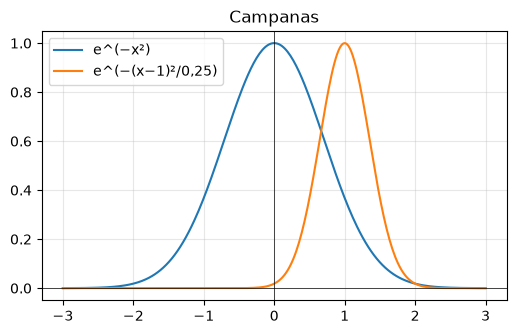

In [9]:
xs = np.linspace(-3, 3, 300)
dibujar(xs, [(np.exp(-xs ** 2), "e^(−x²)"), (np.exp(-(xs - 1) ** 2 / 0.25), "e^(−(x−1)²/0,25)")], "Campanas")

La segunda campana está **desplazada** a x = 1 (sección 1: `x − 1` → el centro donde lo de dentro vale 0) y es más **estrecha**, porque dividimos por 0,25 (que es multiplicar por 4: el cuadrado crece 4 veces más deprisa y la campana cae antes). Con dos números se controla dónde está el centro y cuánto de ancha es. En el NB44 usaremos exactamente esta campana para premiar a un robot por ir **cerca** de una velocidad objetivo; y en el NB28 descubrirás que es la forma de la distribución de probabilidad más importante que existe.


## 3 · El decaimiento exponencial y la constante de tiempo

### Algo que se va apagando

Imagina una taza de chocolate caliente que se enfría, o un muelle que deja de vibrar, o el error de un motor que corrige su posición. En muchas cosas de la naturaleza, **la rapidez con que algo cambia es proporcional a lo que le falta**: cuando falta mucho, cambia deprisa; cuando falta poco, despacio. El resultado es una curva que **se va apagando** sin llegar nunca del todo: el **decaimiento exponencial**:

```
   lo que queda  =  e^(−t / τ)
```

La letra **τ** (tau) se llama **constante de tiempo**, y dice **lo rápido** que se apaga: con τ pequeño, rapidísimo; con τ grande, despacio.


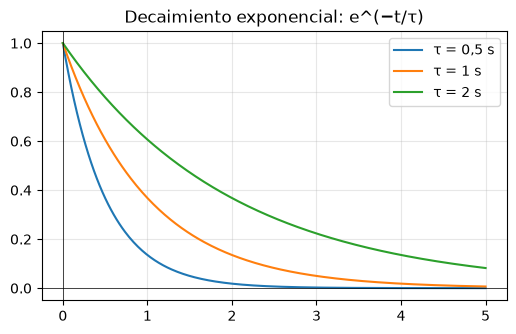

In [10]:
t = np.linspace(0, 5, 300)
dibujar(t, [(np.exp(-t / 0.5), "τ = 0,5 s"), (np.exp(-t / 1.0), "τ = 1 s"), (np.exp(-t / 2.0), "τ = 2 s")],
        "Decaimiento exponencial: e^(−t/τ)")

### El 63 %

¿Qué significa exactamente "constante de tiempo"? Calculemos cuánto queda cuando ha pasado **un τ**, dos, tres...


In [11]:
for veces in [1, 2, 3, 5]:
    queda = np.exp(-veces)
    print(f"tras {veces} τ: queda un {queda:.1%}  →  ha recorrido el {1 - queda:.1%} del camino")

tras 1 τ: queda un 36.8%  →  ha recorrido el 63.2% del camino
tras 2 τ: queda un 13.5%  →  ha recorrido el 86.5% del camino
tras 3 τ: queda un 5.0%  →  ha recorrido el 95.0% del camino
tras 5 τ: queda un 0.7%  →  ha recorrido el 99.3% del camino


**Tras una constante de tiempo, queda el 37 %: se ha recorrido el 63 % del camino.** Tras tres, queda solo un 5 %; tras cinco, menos del 1 % (en la práctica, "ha terminado").

Esta es la definición que usaremos en todo el curso cuando digamos que algo tiene una "constante de tiempo de 0,02 s": que en 0,02 s recorre el 63 % del camino hacia donde va. La verás:

- en los **filtros** que suavizan las medidas de los sensores (NB41),
- en el **contacto** blando de los pies con el suelo (NB48: `timeconst`),
- en la respuesta de un **motor** que no reacciona al instante (NB50: `timeconst`),
- en el **descuento** del aprendizaje por refuerzo (NB29), que hace que las recompensas lejanas valgan cada vez menos.

### Llegar a un objetivo

Y la versión que **sube**: algo que empieza en 0 y va hacia un objetivo (como un vaso que se llena, o un motor que gira hacia su posición) sigue la curva `1 − e^(−t/τ)`: la misma, dada la vuelta (sección 1: `−f` y luego `+ 1`). En t = τ ha llegado al 63 %.


## 4 · El logaritmo: la pregunta inversa

### ¿A qué exponente hay que elevar?

La potencia contesta: "si elevo 10 al cubo, ¿qué sale?" → 10³ = 1.000. El **logaritmo** contesta la pregunta **contraria**: "¿a qué exponente hay que elevar 10 para que salga 1.000?" → **3**. Se escribe:

```
   log₁₀(1.000) = 3       porque 10³ = 1.000
   log₁₀(100) = 2         log₁₀(10) = 1         log₁₀(1) = 0         log₁₀(0,01) = −2
```

El numerito de abajo es la **base**. Con base 10, el logaritmo de una potencia de 10 es... **su número de ceros** (con signo menos para los decimales). Para números que no son potencias exactas, sale un decimal: log₁₀(500) ≈ 2,7 (entre 2 y 3, porque 500 está entre 100 y 1.000). El logaritmo te dice, en resumen, **de qué orden de magnitud** es un número (NB03b).

### Tres bases que verás

| Base | Se escribe | En NumPy | Para qué |
|---|---|---|---|
| 10 | log₁₀ | `np.log10` | órdenes de magnitud, escalas de gráficas |
| 2 | log₂ | `np.log2` | informática: ¿cuántos bits hacen falta? |
| **e** | **ln** (o simplemente **log**) | **`np.log`** | matemáticas, probabilidad, aprendizaje |

El de base **e** se llama **logaritmo natural**, y es el que usan casi todos los matemáticos y programadores. **¡Cuidado!** En NumPy (y en casi toda la programación), **`np.log` es el natural (base e)**, no el de base 10. Es una confusión muy común.


In [12]:
print("log10(1000) =", np.log10(1000))
print("log2(8)     =", np.log2(8), "  ← con 3 bits se cuentan 2³ = 8 valores (NB05b)")
print("log2(256)   =", np.log2(256), "  ← un byte: 8 bits, 256 valores")
print("ln(e)       =", np.log(np.e))
print("ln(1)       =", np.log(1))

log10(1000) = 3.0
log2(8)     = 3.0   ← con 3 bits se cuentan 2³ = 8 valores (NB05b)
log2(256)   = 8.0   ← un byte: 8 bits, 256 valores
ln(e)       = 1.0
ln(1)       = 0.0


Fíjate en el de base 2: `log₂(256) = 8`. ¿Cuántos bits hacen falta para contar 256 valores distintos? Ocho: un byte (NB05b). El logaritmo en base 2 es exactamente "cuántos bits necesito".

### El logaritmo deshace la exponencial

Como el logaritmo es la pregunta inversa de la potencia, **se deshacen** el uno al otro (son operaciones inversas, como sumar y restar, NB04b):

```
   ln(eˣ) = x          e^(ln x) = x
```


In [13]:
x = 3.7
print(np.log(np.exp(x)), np.exp(np.log(x)))

3.7 3.7000000000000006


### Las reglas: multiplicar se convierte en sumar

Y aquí está el superpoder del logaritmo, la razón por la que se inventó hace 400 años (para que los astrónomos y navegantes pudieran multiplicar números enormes a mano): **convierte las multiplicaciones en sumas**. Viene directamente de la regla de las potencias "multiplicar = sumar exponentes" (NB03b):

| Regla | Ejemplo con base 10 |
|---|---|
| **log(a · b) = log(a) + log(b)** | log(100 · 1.000) = 2 + 3 = 5 ✓ (100.000) |
| **log(a / b) = log(a) − log(b)** | log(1.000 / 10) = 3 − 1 = 2 ✓ (100) |
| **log(aⁿ) = n · log(a)** | log(10⁴) = 4 · log(10) = 4 ✓ |
| **log(1 / a) = −log(a)** | log(0,01) = −log(100) = −2 ✓ |

Funcionan con cualquier base (si la misma en todas partes). Comprobémoslas con el logaritmo natural y números cualesquiera:


In [14]:
a, b = 3.0, 7.5
print("ln(a·b) =", np.log(a * b), "| ln(a) + ln(b) =", np.log(a) + np.log(b))
print("ln(a/b) =", np.log(a / b), "| ln(a) − ln(b) =", np.log(a) - np.log(b))
print("ln(a^4) =", np.log(a ** 4), "| 4·ln(a) =", 4 * np.log(a))

ln(a·b) = 3.1135153092103742 | ln(a) + ln(b) = 3.1135153092103742
ln(a/b) = -0.916290731874155 | ln(a) − ln(b) = -0.9162907318741549
ln(a^4) = 4.394449154672439 | 4·ln(a) = 4.394449154672439


¿Por qué importa esto en robótica? En el NB28 verás que la probabilidad de que un robot haga una **secuencia** de acciones es una **multiplicación** de muchísimos números pequeños (0,3 × 0,1 × 0,2 × ...), que enseguida se vuelve tan diminuta que el ordenador la redondea a cero. Con logaritmos, esa multiplicación se convierte en una **suma** de números normales, que el ordenador maneja sin problemas. Es una de las ideas clave del aprendizaje por refuerzo.

### Lo que no tiene logaritmo

Como eˣ siempre es **positivo**, ningún exponente da 0 ni un número negativo. Así que **el logaritmo solo existe para números positivos**:


In [15]:
with np.errstate(divide="ignore", invalid="ignore"):          # (evita avisos en rojo)
    print("ln(0)  =", np.log(0.0))
    print("ln(−1) =", np.log(-1.0))
    print("ln(0,001) =", np.log(0.001), "  ← negativo: los números entre 0 y 1 tienen logaritmo negativo")

ln(0)  = -inf
ln(−1) = nan
ln(0,001) = -6.907755278982137   ← negativo: los números entre 0 y 1 tienen logaritmo negativo


- `ln(0)` da **`-inf`** (menos infinito): para "acercarse" a 0, el exponente tiene que bajar sin límite.
- `ln(−1)` da **`nan`** ("no es un número"): no existe.
- Los números **entre 0 y 1** tienen logaritmo **negativo** (porque hay que elevar e a un exponente negativo para obtenerlos).

(La línea `with np.errstate(...)` le dice a NumPy que no muestre los avisos que daría con estas cuentas imposibles; es un truco que entenderás en la Parte 3. Lo importante son los resultados.)


## 5 · Escalas logarítmicas

### Cuando los datos abarcan muchos órdenes de magnitud

Imagina que dibujas cómo baja el error de un aprendizaje: empieza en 100, y tras un rato vale 0,001. En una gráfica normal, todo lo que pasa por debajo de 1 queda aplastado contra el suelo, invisible. La solución es una **escala logarítmica**: un eje en el que cada marca vale **10 veces** más que la anterior (0,001 - 0,01 - 0,1 - 1 - 10 - 100), en vez de sumar lo mismo cada vez.


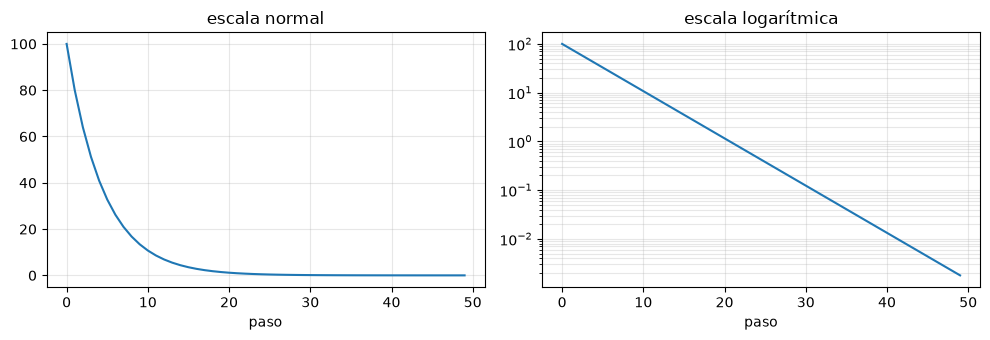

In [16]:
pasos = np.arange(0, 50)
error = 100 * 0.8 ** pasos                     # un error que baja un 20 % en cada paso

fig, ejes = plt.subplots(1, 2, figsize=(10, 3.5))
ejes[0].plot(pasos, error)
ejes[0].set_title("escala normal")
ejes[1].plot(pasos, error)
ejes[1].set_yscale("log")                      # ← el eje vertical, logarítmico
ejes[1].set_title("escala logarítmica")
for eje in ejes:
    eje.set_xlabel("paso")
    eje.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

(Aquí dibujamos dos gráficas una al lado de la otra con `plt.subplots(1, 2)`, que da una lista de dos "ejes"; con cada uno se dibuja por separado. Lo verás más en el NB16.)

En la escala normal, a partir del paso 15 no se ve nada: parece que el error ya es cero. En la escala logarítmica se ve todo... ¡y la curva es una **línea recta**! No es casualidad: el error se multiplica por 0,8 en cada paso (una exponencial, sección 2), y el logaritmo convierte "multiplicar por lo mismo en cada paso" en "sumar lo mismo en cada paso": una recta.

**Regla**: si en escala logarítmica ves una recta, lo que tienes es una **exponencial**. Es una forma muy rápida de reconocerlas en los datos. La usarás en el NB18 para las curvas de aprendizaje y en el NB49 (con los dos ejes logarítmicos) para medir lo rápido que mejora un simulador cuando el paso de tiempo se hace más pequeño.


## 6 · Resumen de la lección

1. **Mover funciones**: `f(x) + c` sube; **`f(x − a)` desplaza a la derecha** (el punto especial va donde lo de dentro vale lo de antes); `c · f(x)` estira (y da la vuelta si c < 0); `f(−x)` refleja. Fuera = vertical y directo; dentro = horizontal y al revés.
2. **Exponencial**: el exponente puede ser cualquier número. aˣ crece multiplicando (a > 1) o decrece (a < 1); **siempre es positiva**.
3. **El número e ≈ 2,718**: crecimiento continuo. `np.exp(x)` = eˣ. Reglas de las potencias. **Campana** `e^(−x²)`: centro y anchura se controlan desplazando y dividiendo.
4. **Decaimiento exponencial** `e^(−t/τ)`: la **constante de tiempo τ** es lo que tarda en recorrer el **63 %** del camino (en 3τ, el 95 %). Subida: `1 − e^(−t/τ)`.
5. **Logaritmo** = "¿a qué exponente?". log₁₀ (órdenes de magnitud), log₂ (bits), **ln = log natural, `np.log`**. Deshace la exponencial: ln(eˣ) = x.
6. **Reglas**: log(a·b) = log a + log b; log(a/b) = log a − log b; log(aⁿ) = n·log a. Convierte multiplicaciones en sumas. Solo existe para positivos; ln(0) = −∞; entre 0 y 1, negativo.
7. **Escala logarítmica**: cada marca ×10. Una **recta en escala log = una exponencial**.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Desplazar / reflejar / estirar** | Mover una curva a un lado, darle la vuelta, hacerla más alta. |
| **ReLU (rampa)** | max(0, x): un codo en el cero. |
| **Función exponencial** | aˣ: el exponente es la variable. |
| **Número e** | ≈ 2,71828: la base del crecimiento continuo. |
| **Campana** | e^(−x²) y sus versiones desplazadas y estiradas. |
| **Decaimiento exponencial** | e^(−t/τ): algo que se apaga, cada vez más despacio. |
| **Constante de tiempo (τ)** | Tiempo en recorrer el 63 % del camino. |
| **Logaritmo** | El exponente al que hay que elevar la base para obtener un número. |
| **Logaritmo natural (ln)** | El de base e; `np.log` en NumPy. |
| **Escala logarítmica** | Eje en el que cada marca vale 10 veces la anterior. |


## 7 · Ejercicios

**E1.** ¿Dónde está el codo de `rampa(x − 3)`? ¿Y el de `rampa(2·x + 1)`? (Pista: donde lo de dentro vale 0.) Compruébalo dibujando.

**E2.** Escribe con la rampa una función que valga 0 para x < 1 y que, a partir de x = 1, **baje** con pendiente 2. Dibújala.

**E3.** Calcula, sin el ordenador, 4^0,5, 8^(1/3) y 10^(−2). Comprueba con el ordenador.

**E4.** Un motor tiene una constante de tiempo de 0,05 s. ¿Qué porcentaje del camino a su objetivo ha recorrido a los 0,05 s? ¿Y a los 0,15 s? ¿Cuándo puedes decir que "ha llegado" (menos del 1 % por recorrer)?

**E5.** Sin ordenador: log₁₀(10.000), log₂(32), ln(1), log₁₀(0,001).

**E6.** Usa la regla del producto para calcular log₁₀(2) + log₁₀(5) sin calcular cada logaritmo por separado.

**E7.** La probabilidad de 100 acciones seguidas es 0,1¹⁰⁰. ¿Qué número da el ordenador? Calcula su logaritmo natural con la regla de las potencias (en vez de calcular primero 0,1¹⁰⁰). ¿Por qué es mejor así?

**E8.** Dibuja `2ˣ` y `x²` para x entre 0 y 10 en escala logarítmica vertical. ¿Cuál sale recta? ¿Por qué?


<details>
<summary>▶ Solución E1</summary>

- `rampa(x − 3)`: x − 3 = 0 → **x = 3**.
- `rampa(2·x + 1)`: 2·x + 1 = 0 → 2·x = −1 → **x = −0,5**. (Además, el 2 dentro hace que la rampa suba el doble de deprisa.)

```python
xs = np.linspace(-4, 4, 401)
dibujar(xs, [(rampa(xs - 3), "rampa(x − 3)"), (rampa(2 * xs + 1), "rampa(2x + 1)")], "E1")
```
</details>

<details>
<summary>▶ Solución E2</summary>

Codo en x = 1: `rampa(x − 1)`. Que **baje** con pendiente 2: multiplicar por **−2**:

```python
dibujar(xs, [(-2 * rampa(xs - 1), "−2·rampa(x − 1)")], "E2")
```

Vale 0 hasta x = 1 y después baja 2 unidades por cada unidad de x.
</details>

<details>
<summary>▶ Solución E3</summary>

- 4^0,5 = √4 = **2**.
- 8^(1/3) = ∛8 = **2** (porque 2 × 2 × 2 = 8; un tercio como exponente es la raíz cúbica).
- 10^(−2) = 1/100 = **0,01**.

```python
print(4 ** 0.5, 8 ** (1 / 3), 10 ** -2)       # 2.0  2.0  0.01
```

(Puede salir `1.9999999999999998` para la raíz cúbica: el ruido de los decimales del NB05b.)
</details>

<details>
<summary>▶ Solución E4</summary>

A los 0,05 s = **1 τ**: ha recorrido el **63 %**. A los 0,15 s = **3 τ**: el **95 %**. "Ha llegado" (menos del 1 % por recorrer) a partir de **5 τ = 0,25 s** (queda e⁻⁵ ≈ 0,7 %).
</details>

<details>
<summary>▶ Solución E5</summary>

- log₁₀(10.000) = **4** (cuatro ceros).
- log₂(32) = **5** (2⁵ = 32).
- ln(1) = **0** (cualquier base elevada a 0 da 1).
- log₁₀(0,001) = **−3** (0,001 = 10⁻³).
</details>

<details>
<summary>▶ Solución E6</summary>

log₁₀(2) + log₁₀(5) = log₁₀(2 · 5) = log₁₀(10) = **1**. Sin calcular ninguno de los dos por separado (que son 0,301 y 0,699).
</details>

<details>
<summary>▶ Solución E7</summary>

```python
print(0.1 ** 100)                    # 1.0000000000000056e-100: aún cabe, pero rozando el límite
print(0.1 ** 400)                    # 0.0: ¡demasiado pequeño! el ordenador lo redondea a cero
print(100 * np.log(0.1))             # ln(0,1^100) = 100 · ln(0,1) = -230.26, un número normalísimo
```

Con la regla `ln(aⁿ) = n · ln(a)`, no hace falta calcular nunca el número diminuto: se calcula directamente su logaritmo, −230,26, que el ordenador maneja sin problema. Con 400 acciones, la probabilidad directa ya sale **0** (el ordenador no puede guardar números tan pequeños), pero su logaritmo, −921, sigue siendo perfectamente manejable. Por eso, en el aprendizaje por refuerzo, siempre se trabaja con **logaritmos de probabilidades** (NB28).
</details>

<details>
<summary>▶ Solución E8</summary>

```python
xs = np.linspace(0.1, 10, 200)
plt.figure(figsize=(6, 3.5))
plt.plot(xs, 2 ** xs, label="2^x")
plt.plot(xs, xs ** 2, label="x²")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()
```

**2ˣ** sale recta: es una exponencial (se multiplica por 2 cada vez que x sube 1), y en escala logarítmica las exponenciales son rectas. **x²** sale curvada: no se multiplica por lo mismo en cada paso (de 1 a 2 se multiplica por 4; de 9 a 10, solo por 1,23). Y fíjate en que, aunque al principio x² es mayor, la exponencial acaba **adelantándola** muchísimo: el crecimiento exponencial siempre gana a largo plazo.
</details>


## 8 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

En el **NB16**, las **pendientes**: cuánto sube una curva en cada punto. Es la herramienta con la que un robot sabrá hacia dónde mover sus ruedecillas para mejorar. Y las curvas de hoy (la rampa, la exponencial, la campana) serán perfectas para practicar.
